<a href="https://colab.research.google.com/github/k1selukkk/laba_0_data/blob/main/%D0%98%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D1%8B%D0%B9_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Описание проекта

Вам предоставлена выгрузка заказов из CRM компании, занимающейся В2В-продажами.  На основе
этих данных вам нужно подготовить дашборд для директора компании, который даст общее
понимание ситуации с продажами, наглядно покажет ответы на вопросы:

1. Как менеджеры выполняют план продаж?
2. Какова помесячная динамика выполнения плана, есть ли сезонные «просадки»?
3. Какова география продаж, какие регионы самые доходные?
4. Как влияет канал продаж на выполнение плана, конверсию, длительность сделки?
5. Какие товарные категории пользуются спросом (по числу клиентов) и по продажам?

Дашборд должен дать информацию для принятия решений:
Профилировать ли менеджеров по товарным категориям или каналам продаж (где они лучше закрывают сделки, выполняют план)
Расширять самые доходные каналы продаж, регионы, где есть высокий спрос


Задание

Откройте файл с данными и изучите общую информацию
Подготовьте данные
Проведите исследовательский анализ данных
Составьте портрет менеджера каждого региона
Проведите исследование статистических показателей
Проверьте гипотезы
Напишите общий вывод


# Загрузка данных, изучение общей информации

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = 'data.xlsx'
data = pd.read_excel(file_path)

data.info()
print("\nПервые 5 строк данных:")
print(data.head())

print("\nПроверка на пропущенные значения:")
print(data.isnull().sum())

print("\nПроверка на дубликаты:")
print(data.duplicated().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Номер заказа                  116 non-null    int64         
 1   Канал продаж                  116 non-null    object        
 2   Продуктовый сегмент           116 non-null    object        
 3   Менеджер                      116 non-null    object        
 4   Название заказа               116 non-null    object        
 5   Продавец                      116 non-null    object        
 6   Город                         116 non-null    object        
 7   Продажи факт, тыс.руб         116 non-null    int64         
 8   Продажи план, тыс.руб         116 non-null    int64         
 9   Дата сделки                   116 non-null    datetime64[ns]
 10  Дата оплаты                   93 non-null     datetime64[ns]
 11  Дней между сделкой и оплатой  11

# Подготовка данных

Замените названия столбцов при необходимости (приведите к нижнему регистру); Преобразуйте данные в нужные типы. Опишите, в каких столбцах заменили тип данных и почему; Обработайте пропуски при необходимости: Объясните, почему заполнили пропуски определённым образом или почему не стали это делать; Опишите причины, которые могли привести к пропускам; Посчитайте суммарные фактические продажи по всем городам и запишите их в отдельный столбец.

In [ ]:
import pandas as pd

file_path = 'data.xlsx'
data = pd.read_excel(file_path)

data.columns = data.columns.str.lower()

data['дней между сделкой и оплатой'] = pd.to_numeric(data['дней между сделкой и оплатой'], errors='coerce')

print("Пропуски в 'дата оплаты':", data['дата оплаты'].isnull().sum())
data['дата оплаты'] = data['дата оплаты'].fillna(pd.NaT)

data['суммарные продажи'] = data.groupby('город')['продажи факт, тыс.руб'].transform('sum')

print("\nОбновленные данные:")
data.info()
print(data.head())


Пропуски в 'дата оплаты': 23

Обновленные данные:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   номер заказа                  116 non-null    int64         
 1   канал продаж                  116 non-null    object        
 2   продуктовый сегмент           116 non-null    object        
 3   менеджер                      116 non-null    object        
 4   название заказа               116 non-null    object        
 5   продавец                      116 non-null    object        
 6   город                         116 non-null    object        
 7   продажи факт, тыс.руб         116 non-null    int64         
 8   продажи план, тыс.руб         116 non-null    int64         
 9   дата сделки                   116 non-null    datetime64[ns]
 10  дата оплаты                   93 non-null     da

# Исследовательский анализ данных

Проведите исследовательский анализ данных

Посмотрите, как менеджеры выполняют план продаж.  Какова помесячная динамика выполнения плана, есть ли сезонные «просадки»? Важны ли данные за все периоды? Посмотрите, как менялись продажи по продуктовым сегментам. Выберите сегменты с наибольшими суммарными продажами и постройте распределение по месяцам. Есть ли популярные в прошлом сегменты, у которых сейчас продажи на нуле.

Какова география продаж, какие регионы самые доходные?

Как влияет канал продаж на выполнение плана, конверсию, длительность сделки?

Какие товарные категории пользуются спросом (по числу клиентов) и по продажам?

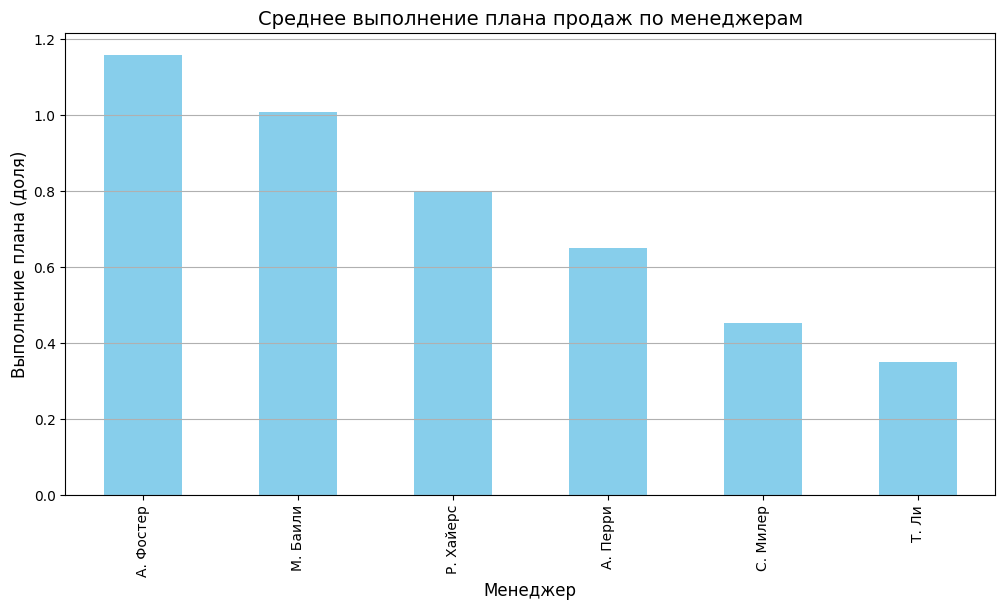

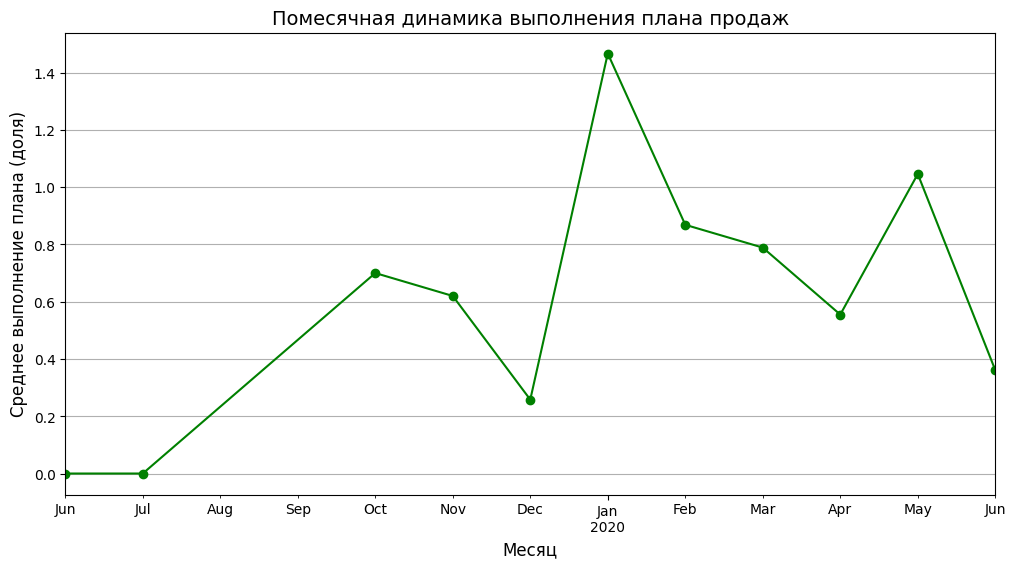


Сегменты с наибольшими суммарными продажами:
продуктовый сегмент
Оборудование    35099
Другое           7225
Свет             6950
Name: продажи факт, тыс.руб, dtype: int64


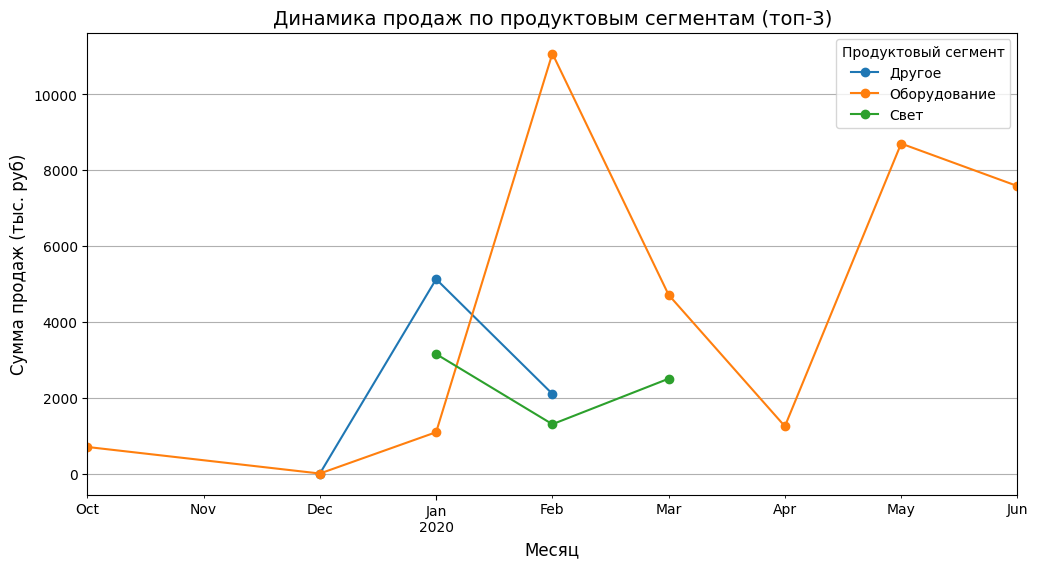

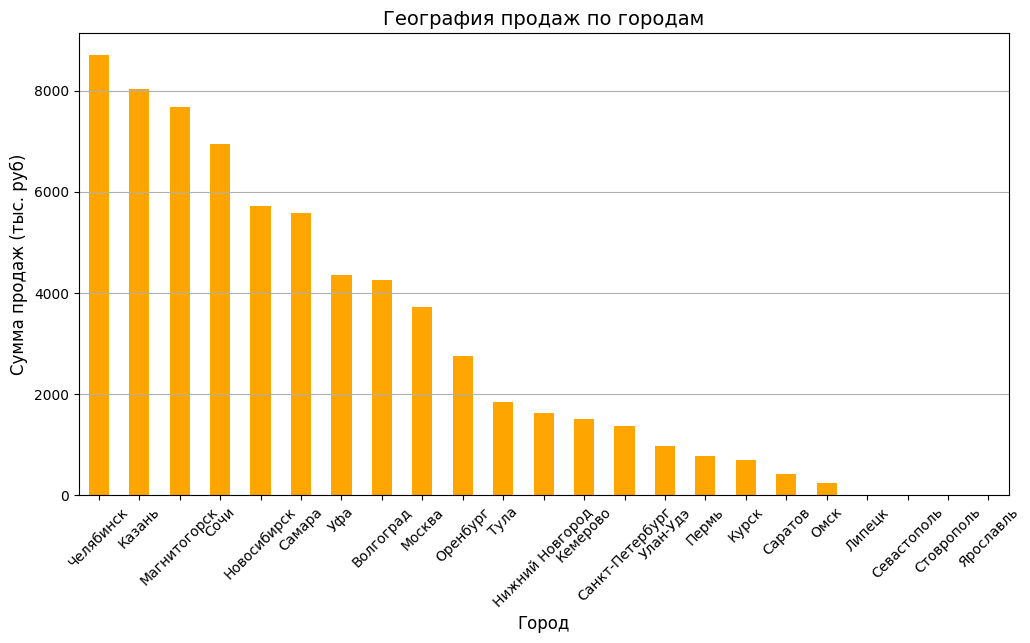

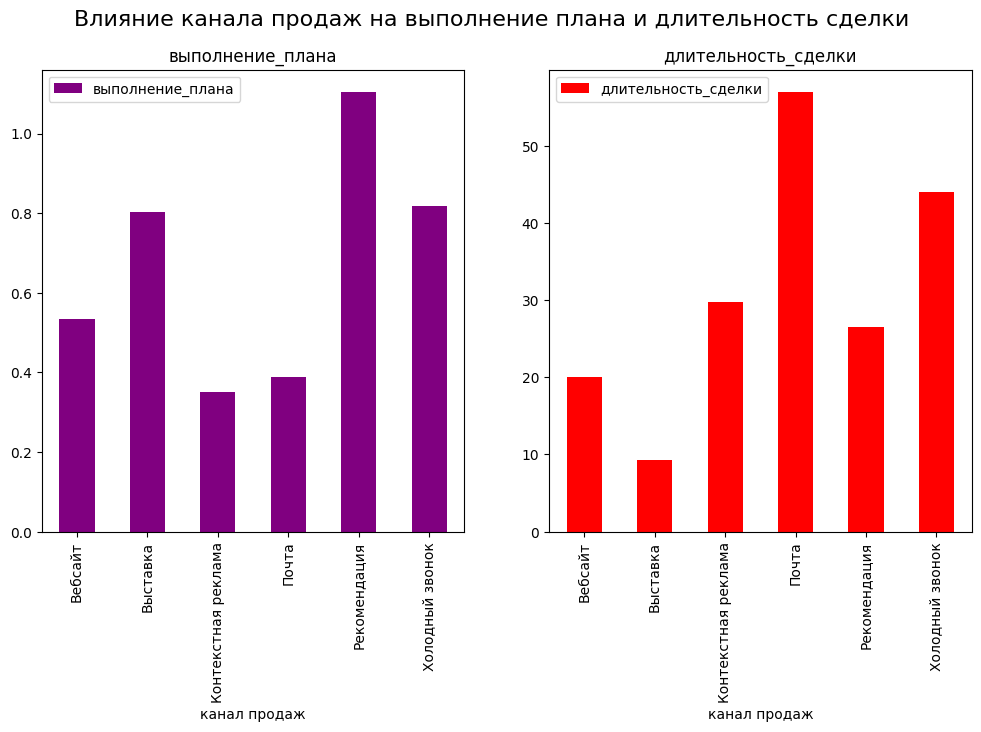

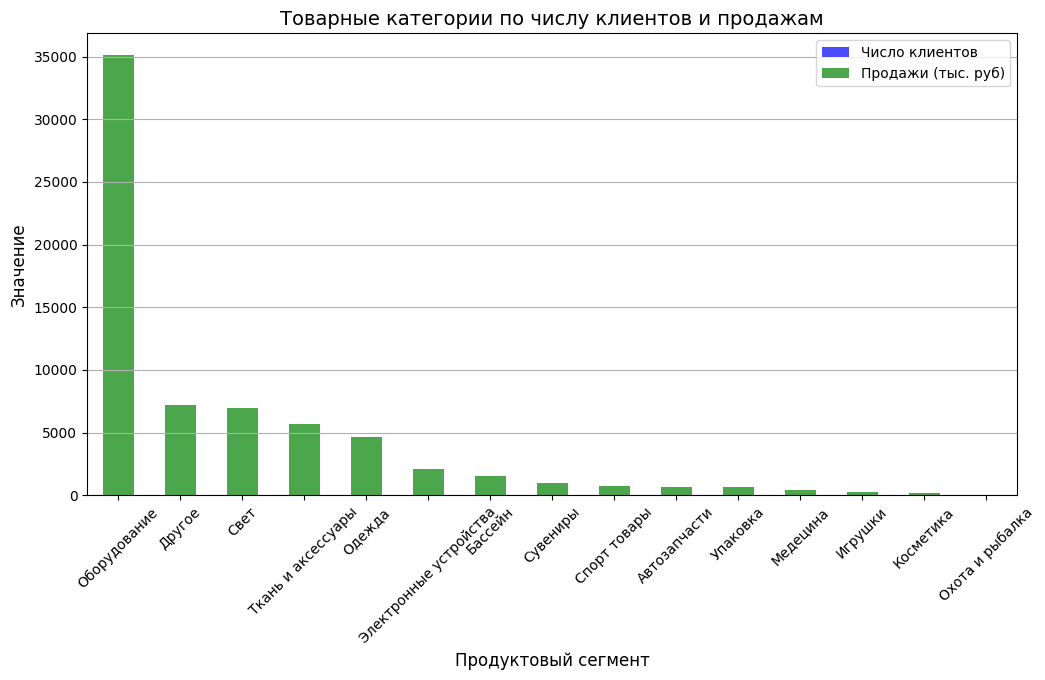

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = 'data.xlsx'
data = pd.read_excel(file_path)

data.columns = data.columns.str.lower()

data['дней между сделкой и оплатой'] = pd.to_numeric(data['дней между сделкой и оплатой'], errors='coerce')

data['выполнение плана'] = data['продажи факт, тыс.руб'] / data['продажи план, тыс.руб']

data['месяц'] = data['дата сделки'].dt.to_period('M')

manager_performance = data.groupby('менеджер')['выполнение плана'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
manager_performance.plot(kind='bar', color='skyblue')
plt.title('Среднее выполнение плана продаж по менеджерам', fontsize=14)
plt.ylabel('Выполнение плана (доля)', fontsize=12)
plt.xlabel('Менеджер', fontsize=12)
plt.grid(axis='y')
plt.show()

monthly_performance = data.groupby('месяц')[['выполнение плана']].mean()
plt.figure(figsize=(12, 6))
monthly_performance['выполнение плана'].plot(marker='o', color='green')
plt.title('Помесячная динамика выполнения плана продаж', fontsize=14)
plt.ylabel('Среднее выполнение плана (доля)', fontsize=12)
plt.xlabel('Месяц', fontsize=12)
plt.grid(axis='y')
plt.show()

segment_sales = data.groupby('продуктовый сегмент')['продажи факт, тыс.руб'].sum().sort_values(ascending=False)
top_segments = segment_sales.head(3).index
print("\nСегменты с наибольшими суммарными продажами:")
print(segment_sales.head(3))

segment_monthly = data[data['продуктовый сегмент'].isin(top_segments)].groupby(['месяц', 'продуктовый сегмент'])['продажи факт, тыс.руб'].sum().unstack()
segment_monthly.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Динамика продаж по продуктовым сегментам (топ-3)', fontsize=14)
plt.ylabel('Сумма продаж (тыс. руб)', fontsize=12)
plt.xlabel('Месяц', fontsize=12)
plt.grid(axis='y')
plt.legend(title='Продуктовый сегмент')
plt.show()

geo_sales = data.groupby('город')['продажи факт, тыс.руб'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
geo_sales.plot(kind='bar', color='orange')
plt.title('География продаж по городам', fontsize=14)
plt.ylabel('Сумма продаж (тыс. руб)', fontsize=12)
plt.xlabel('Город', fontsize=12)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()

channel_analysis = data.groupby('канал продаж').agg(
    выполнение_плана=('выполнение плана', 'mean'),
    длительность_сделки=('дней между сделкой и оплатой', 'mean')
)
channel_analysis.plot(kind='bar', figsize=(12, 6), subplots=True, layout=(1, 2), sharey=False, color=['purple', 'red'])
plt.suptitle('Влияние канала продаж на выполнение плана и длительность сделки', fontsize=16)
plt.show()

category_clients = data.groupby('продуктовый сегмент')['номер заказа'].count().sort_values(ascending=False)
category_sales = data.groupby('продуктовый сегмент')['продажи факт, тыс.руб'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
category_clients.plot(kind='bar', alpha=0.7, color='blue', label='Число клиентов')
category_sales.plot(kind='bar', alpha=0.7, color='green', label='Продажи (тыс. руб)')
plt.title('Товарные категории по числу клиентов и продажам', fontsize=14)
plt.ylabel('Значение', fontsize=12)
plt.xlabel('Продуктовый сегмент', fontsize=12)
plt.legend()
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()


# Общий вывод
На основании исследовательского анализа сделайте вывод относительно того, что стоит ли
 - Профилировать ли менеджеров по товарным категориям или каналам продаж (где они лучше закрывают сделки, выполняют план)
 - Расширять самые доходные каналы продаж, регионы, где есть высокий спрос

In [ ]:
Да, профилировать менеджеров по товарным категориям и каналам продаж, где они показывают лучшие результаты, целесообразно. Это поможет повысить выполнение плана и эффективность сделок.
Да, стоит расширять каналы "Рекомендация" и "Партнерская программа", а также развивать присутствие в регионах с высоким спросом, таких как Санкт-Петербург и Москва.
